# 頭皮 Grid 法向量 與 髮絲存取 示範（per-strand 上色版）

這本 notebook 示範兩件事：

1. **讀取髮絲**：DiffLocks 資料集裡髮絲怎麼存、如何存取單根髮絲 / 一批髮絲（髮束）。
2. **頭皮 grid 法向量**：把頭皮切成 n×n grid 後，如何存取每個 grid cell 對應的 3D 位置與法向量。

跟原版 `scalp_grid_and_strands_demo.ipynb` 的差異在第 5、6 節：這裡改成把自訂的 n×n color matrix
直接轉成**逐髮絲 (per-strand)** 的 `highlighted` / `highlight_color`，存成
`coloring_by_strand/generate_highlight_templates_by_strand.py` 認得的 template 格式，並改呼叫
`coloring_by_strand/generate_highlight_render_by_strand.py` 渲染——不再是 `coloring_by_grid` 那種
「n×n grid template，渲染時逐格查表」的做法。

用到的函式定義在同資料夾的 `scalp_grid.py`、`hair_query.py`、`ply_io.py`（在前面對話中建立），
以及 `../scalp_uv_grid.py`（`coloring_by_strand` pipeline 共用的 UV<->grid 換算）。

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 這個 notebook 放在 .../highlighting/generate_from_3D_models/scalp_grid_volume_sample/ 底下,
# 但同資料夾的模組是用「package 形式」匯入
# (from highlighting.generate_from_3D_models.scalp_grid_volume_sample.xxx import ...),
# 所以要把專案根目錄 (P76154862) 加進 sys.path,Python 才找得到 `highlighting` 這個套件。
HERE = "/home/kyh/Desktop/P76154862/highlighting/generate_from_3D_models/scalp_grid_volume_sample"
PROJECT_ROOT = os.path.abspath(os.path.join(HERE, "..", "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from highlighting.generate_from_3D_models.scalp_grid_volume_sample.scalp_grid import (
    load_scalp_mesh, build_scalp_grid, tangent_frame, nearest_valid_cell,
)
from highlighting.generate_from_3D_models.scalp_grid_volume_sample.hair_query import (
    load_strands, strands_above_cell, strands_above_cells, strands_above_cells_gpu,
    root_density_map, estimate_half_size,
)
from highlighting.generate_from_3D_models.scalp_grid_volume_sample.tool_functions import (
    show_color_matrix, draw_strand_uv_color_distribution, apply_median_color_to_strands,
    save_template_npz, run_blender_render,
)

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /home/kyh/Desktop/P76154862


## 1. 讀取頭皮 mesh，建立 n×n grid

In [2]:
# main.py 裡 DEFAULT_DATASET_ROOT 是用 os.path.dirname(HERE) 推算,
# 但這個資料夾被搬進 highlighting/ 專案後那個預設值已經不對了 (會指到 generate_from_3D_models/),
# 這裡直接指到實際的 DiffLocks_Dataset 位置。
DATASET_ROOT = os.path.join(PROJECT_ROOT, "DiffLocks_Dataset", "difflocks_dataset")
SCALP_PLY = os.path.join(DATASET_ROOT, "body_data", "scalp.ply")

positions, normals, uv, faces = load_scalp_mesh(SCALP_PLY)
print(f"scalp mesh: {positions.shape[0]} vertices, {faces.shape[0]} faces")

N = 32  # grid 解析度 (n x n)
grid_uv, grid_pos, grid_normal, grid_valid, (us, vs) = build_scalp_grid(
    positions, normals, uv, faces, N
)

print(f"grid_pos.shape    = {grid_pos.shape}     # (N, N, 3) 每格在頭皮表面的 3D 位置")
print(f"grid_normal.shape = {grid_normal.shape}  # (N, N, 3) 每格的法向量")
print(f"grid_valid.shape  = {grid_valid.shape}   # (N, N) bool, 是否落在頭皮的 UV 範圍內")
print(f"有效 (落在頭皮上) 的 cell 數: {grid_valid.sum()} / {grid_valid.size}")

scalp mesh: 513 vertices, 946 faces
grid_pos.shape    = (32, 32, 3)     # (N, N, 3) 每格在頭皮表面的 3D 位置
grid_normal.shape = (32, 32, 3)  # (N, N, 3) 每格的法向量
grid_valid.shape  = (32, 32)   # (N, N) bool, 是否落在頭皮的 UV 範圍內
有效 (落在頭皮上) 的 cell 數: 730 / 1024


## 2. 存取單一 grid cell 的法向量

`grid_pos` / `grid_normal` 都是規則的 `(N, N, 3)` array，直接用 `[i, j]` 索引就能拿到該格的位置與法向量——
不需要額外查找。若 `(i, j)` 不在頭皮上（`grid_valid[i, j] == False`），用 `nearest_valid_cell` 找最近的有效格。

In [3]:
i, j = N // 2, N // 2
i, j = nearest_valid_cell(grid_valid, i, j)

cell_pos    = grid_pos[i, j]     # (3,) 這一格在頭皮表面的 3D 位置
cell_normal = grid_normal[i, j]  # (3,) 這一格的法向量 (已正規化)

print(f"grid cell ({i}, {j})")
print("  位置 (position):", cell_pos)
print("  法向量 (normal):", cell_normal, " |n| =", np.linalg.norm(cell_normal))

grid cell (16, 16)
  位置 (position): [-0.017234    0.39617933 -0.07771098]
  法向量 (normal): [-0.18432527  0.80447181 -0.56466743]  |n| = 0.9999999999989937


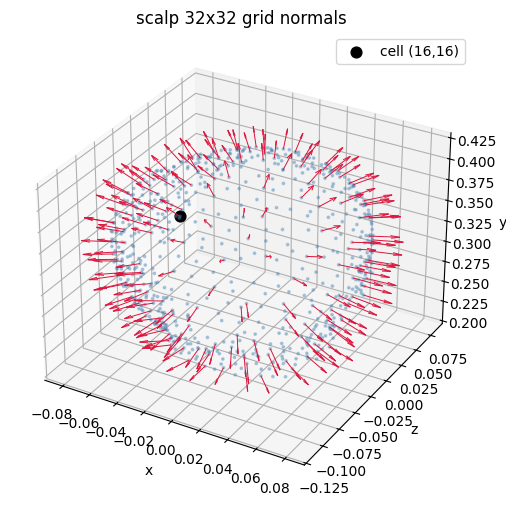

In [4]:
# 視覺化整個 grid 的法向量分布 (紅色箭頭), 黑點 = 上面查詢的 cell
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

valid_pos = grid_pos[grid_valid]
ax.scatter(valid_pos[:, 0], valid_pos[:, 2], valid_pos[:, 1], s=3, alpha=0.35, color="steelblue")

stride = 2
sv = grid_valid[::stride, ::stride]
sp = grid_pos[::stride, ::stride][sv]
sn = grid_normal[::stride, ::stride][sv]
ax.quiver(sp[:, 0], sp[:, 2], sp[:, 1], sn[:, 0], sn[:, 2], sn[:, 1], length=0.02, color="crimson", linewidth=0.7)

ax.scatter([cell_pos[0]], [cell_pos[2]], [cell_pos[1]], color="black", s=60, label=f"cell ({i},{j})")
ax.set_xlabel("x"); ax.set_ylabel("z"); ax.set_zlabel("y")
ax.set_title(f"scalp {N}x{N} grid normals")
ax.legend()
plt.show()

## 3. 讀取髮絲資料

strand_positions: (96821, 256, 3) float32
root_uv         : (96821, 2)
root_normal     : (96821, 3)


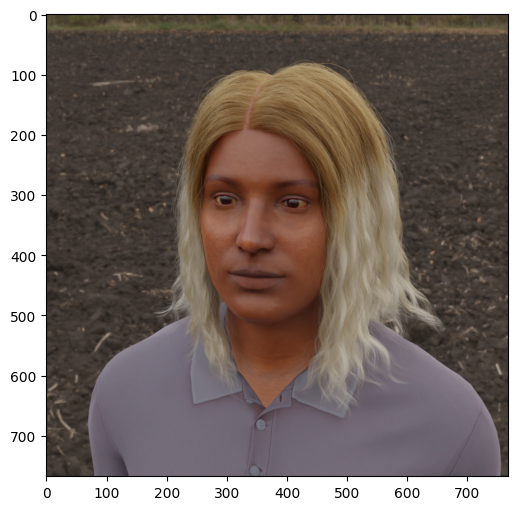

In [5]:
HAIRSTYLE_DIR = os.path.join(DATASET_ROOT, "generated_hairstyles", "base_13_idx_94847")
STRANDS_NPZ = os.path.join(HAIRSTYLE_DIR, "full_strands.npz")

strand_positions, root_uv, root_normal = load_strands(STRANDS_NPZ)
print("strand_positions:", strand_positions.shape, strand_positions.dtype)  # (S, P, 3)
print("root_uv         :", root_uv.shape)   # (S, 2)  每根髮絲髮根在頭皮 UV 上的座標
print("root_normal     :", root_normal.shape)  # (S, 3)  髮根法向量

RGB=os.path.join(HAIRSTYLE_DIR, 'rgb.png')
img = plt.imread(RGB)
plt.figure(figsize=(6, 6))
plt.imshow(img)

### 3.1 單根髮絲存取

直接用整數索引即可：`positions[k]` 拿到整條折線，`root_uv[k]` / `root_normal[k]` 是它的髮根資訊。

In [6]:
k = 12345
strand_k = strand_positions[k]  # (P, 3): 這根髮絲所有取樣點 (P=256)

print(f"strand[{k}].shape = {strand_k.shape}")
print("  髮根 (第0點):", strand_k[0])
print("  髮尾 (末點) :", strand_k[-1])
print("  root_uv     :", root_uv[k])
print("  root_normal :", root_normal[k])

seg_len = np.linalg.norm(np.diff(strand_k, axis=0), axis=1).sum()
print(f"  髮絲長度 (折線段長度加總) ≈ {seg_len:.4f}")

strand[12345].shape = (256, 3)
  髮根 (第0點): [-0.07470686  0.33914936  0.0088485 ]
  髮尾 (末點) : [-0.0667513   0.19599423 -0.00467904]
  root_uv     : [0.8259088  0.63214713]
  root_normal : [0.970308   0.06207009 0.23377272]
  髮絲長度 (折線段長度加總) ≈ 0.1575


### 3.2 一批髮絲（髮束）：拿 grid cell 的位置 + 法向量，找出「這一格正上方」的髮絲

資料本身沒有內建的髮束/群組 id，所以用第 2 節拿到的 `cell_pos` / `cell_normal` 建立一個沿法向量延伸的局部柱體，
測試每根髮絲的取樣點是否落在柱體內（`strands_above_cell`），藉此把「頭皮某一格」跟「它上面的一撮頭髮」連結起來。

In [7]:
t1, t2 = tangent_frame(cell_normal)               # 該 cell 的切線方向 (與法向量共同組成局部座標系)
half_size = estimate_half_size(grid_pos, grid_valid)  # 柱體的橫截面半徑 (預設用 grid 間距估計)

strand_mask, point_mask, local_h = strands_above_cell(
    strand_positions, cell_pos, cell_normal, t1, t2,
    half_size=half_size, h_min=-0.01, h_max=0.4,
)
bundle_idx = np.where(strand_mask)[0]
bundle = strand_positions[bundle_idx]  # (K, P, 3): 這一整束髮絲

print(f"grid cell ({i}, {j}) 上方共有 {bundle_idx.size} 根髮絲")
print("前 10 個 strand index:", bundle_idx[:10])
print("bundle.shape =", bundle.shape)

grid cell (16, 16) 上方共有 443 根髮絲
前 10 個 strand index: [12263 14325 14326 14327 14330 14333 14334 14335 14336 14337]
bundle.shape = (443, 256, 3)


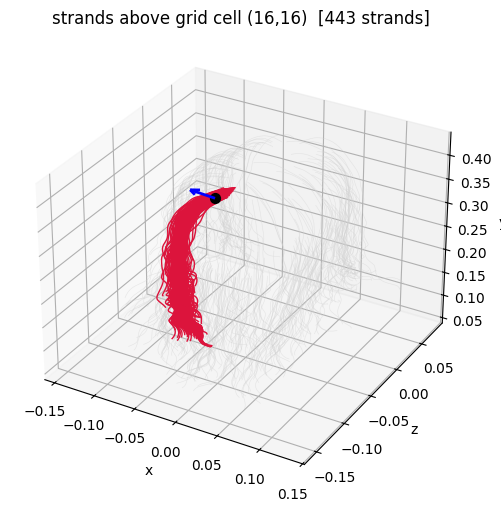

In [8]:
# 視覺化: 灰色 = 隨機取樣的其他髮絲 (背景參考), 紅色 = 這個 grid cell 上方找到的髮束
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

rng = np.random.default_rng(0)
ctx_idx = rng.choice(strand_positions.shape[0], size=300, replace=False)
for idx in ctx_idx:
    s = strand_positions[idx]
    ax.plot(s[:, 0], s[:, 2], s[:, 1], color="lightgray", linewidth=0.4, alpha=0.5)
for idx in bundle_idx:
    s = strand_positions[idx]
    ax.plot(s[:, 0], s[:, 2], s[:, 1], color="crimson", linewidth=1.0)

ax.scatter([cell_pos[0]], [cell_pos[2]], [cell_pos[1]], color="black", s=50)
ax.quiver(cell_pos[0], cell_pos[2], cell_pos[1],
          cell_normal[0], cell_normal[2], cell_normal[1], length=0.05, color="blue", linewidth=2)
ax.set_title(f"strands above grid cell ({i},{j})  [{bundle_idx.size} strands]")
ax.set_xlabel("x"); ax.set_ylabel("z"); ax.set_zlabel("y")
plt.show()

## 小結

| 想要什麼 | 怎麼存取 |
|---|---|
| 頭皮某個 grid cell 的 3D 位置 | `grid_pos[i, j]` |
| 頭皮某個 grid cell 的法向量 | `grid_normal[i, j]` |
| 該 cell 是否真的落在頭皮上 | `grid_valid[i, j]` |
| 單根髮絲的所有取樣點 | `strand_positions[k]` -> `(P, 3)` |
| 單根髮絲的髮根 UV / 法向量 | `root_uv[k]` / `root_normal[k]` |
| 某個 grid cell 正上方的一批髮絲 | `strands_above_cell(strand_positions, grid_pos[i,j], grid_normal[i,j], ...)` -> `strand_mask` -> `strand_positions[strand_mask]` |


## 4. 用同樣的資料畫出「整個頭」(body mesh + 全部髮絲)

`body_data/smplx_base.ply` 其實是**整個 SMPL-X 身體** mesh（含軀幹/四肢，y 範圍 -1.3 ~ 0.42），
不是只有頭。這裡示範怎麼：

1. 只裁切出頭部 + 脖子附近的三角形（用 y 座標做簡單門檻篩選）
2. 用面法向量 · 光源方向做一個很陽春的 Lambertian 上色，讓頭型看得出立體感
3. 疊加一大批髮絲（`strand_positions`，前面第 3 節已經讀進來的 `full_strands.npz`）畫成線段

matplotlib 的 3D 只是把每個圖元投影後畫出來，**沒有真正的 z-buffer**，所以不同 `Poly3DCollection` /
`Line3DCollection` 之間的前後遮擋不會完全正確（臉上偶爾會看到穿過去的髮絲雜點）。要正確的前後遮擋、
即時互動旋轉，會建議之後換成 PyVista/VTK/Blender 之類的真正 3D renderer；這裡純粹是「資料到底長怎樣」
的靜態示意圖。

In [9]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection

BODY_PLY = os.path.join(DATASET_ROOT, "body_data", "smplx_base.ply")
body_pos, body_normals, body_uv, body_faces = load_scalp_mesh(BODY_PLY)
print(f"body mesh: {body_pos.shape[0]} vertices, {body_faces.shape[0]} faces "
      f"(y range {body_pos[:,1].min():.2f} ~ {body_pos[:,1].max():.2f})")

# 只留頭 + 脖子 (脖子在 y~0.1~0.2 附近變窄, 肩膀在更下面展開)
Y_MIN = 0.08
keep_v = body_pos[:, 1] > Y_MIN
head_faces = body_faces[keep_v[body_faces].all(axis=1)]
print(f"裁切後留下 {head_faces.shape[0]} / {body_faces.shape[0]} 個三角形")

tri = body_pos[head_faces]                      # (F, 3, 3)
face_normal = np.cross(tri[:, 1] - tri[:, 0], tri[:, 2] - tri[:, 0])
face_normal /= np.linalg.norm(face_normal, axis=1, keepdims=True) + 1e-9

light_dir = np.array([0.3, 0.6, 0.8]); light_dir /= np.linalg.norm(light_dir)
shade = np.clip(face_normal @ light_dir, 0.15, 1.0)       # 陽春 Lambertian 光照
skin_color = np.array([0.85, 0.70, 0.60])
face_colors = skin_color[None, :] * shade[:, None]

body mesh: 11307 vertices, 20908 faces (y range -1.30 ~ 0.42)
裁切後留下 10206 / 20908 個三角形


## 5. 自訂 n×n Color Matrix，直接轉成逐髮絲 (per-strand) 顏色

延續第 1 節「頭皮 UV → n×n grid」的做法，一樣手動自訂一個 n×n 的顏色矩陣（每一格是一個 RGB 顏色），
鋪在頭皮 UV 空間上；但這次不是把矩陣存成「grid template」讓 Blender 在渲染時逐格查表（`coloring_by_grid`
的做法），而是**在 notebook 這裡就把每一根髮絲的顏色算好**，變成 `highlighted` / `highlight_color`
這兩個逐髮絲 (per-strand) 的 array —— 跟 `coloring_by_strand/generate_highlight_templates_by_strand.py`
產生的 template 是同一種資料格式。

UV → grid 的 row/col 換算直接呼叫 `scalp_uv_grid.py` 的 `build_uv_bin_edges` / `uv_to_grid_rowcol` /
`grid_cell_centers_rowcol`，跟 `coloring_by_strand` pipeline 用的是同一套慣例（row 0 = UV 高 v 端，
跟其他 template PNG / `scalp_grid_rgb.jpg` 一致），不再像舊版那樣自己用 `searchsorted` 土法煉鋼。

color_matrix.shape = (32, 32, 3)


/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24050 (\N{CJK UNIFIED IDEOGRAPH-5DF2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32763 (\N{CJK UNIFIED IDEOGRAPH-7FFB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36681 (\N{CJK UNIFIED IDEOGRAPH-8F49}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-81EA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35330 (\N{CJK UNIFIED IDEOGRAPH-8A02}) missing from fon

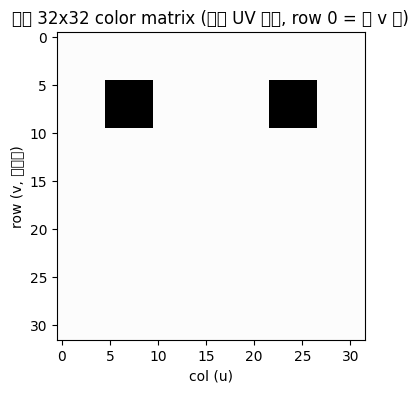

<Axes: title={'center': '自訂 32x32 color matrix (頭皮 UV 空間, row 0 = 高 v 端)'}, xlabel='col (u)', ylabel='row (v, 已翻轉)'>

In [35]:
import colorsys

from highlighting.generate_from_3D_models.scalp_uv_grid import (
    build_uv_bin_edges, grid_cell_centers_rowcol, load_scalp_uv, uv_to_grid_rowcol,
)

# ---- 自訂你的 n x n color matrix ----------------------------------------
# color_matrix[row, col] = 該格的 RGB (0~1)。row/col 跟 scalp_uv_grid.uv_to_grid_rowcol()
# 的慣例一致：col 隨 u 增加 (左->右)，row 是 v 軸翻轉過的 (row 0 = UV 高 v 端)。
# grid 解析度統一沿用第 1 節定義的 N（頭皮 mesh n x n grid 用的同一個 N），不再另外自訂一組 n_color。
# 這裡示範一個由左到右的彩虹橫條 (每一列重複同樣的橫向漸層)，純粹是「怎麼定義矩陣」的範例——
# 你可以整個換成手動填值、棋盤格、由圖片讀入等任何 N x N x 3 的 array。
hues = np.linspace(0.0, 1.0, N, endpoint=False)
row_colors = np.array([colorsys.hls_to_rgb(h, 0.5, 0.85) for h in hues])  # (N, 3)
color_matrix = np.tile(row_colors[None, :, :], (N, 1, 1))  # (N, N, 3)

# 也可以改成手動逐格指定，例如只想染前兩格、其餘維持某個底色，取消註解試試：
base_color = np.array([0.99, 0.99, 0.99])  # 

highlight_color_swatch = np.array([0.0, 0.0, 0.0])  # 亮紫色
color_matrix = np.tile(np.array(base_color), (N, N, 1))
color_matrix[5:10, 5:10] = highlight_color_swatch  # (row=2, col=1) 這一格改成亮紫色
color_matrix[5:10, -10:-5] = highlight_color_swatch  # (row=2, col=1) 這一格改成亮紫色
# color_matrix[2:15, 2:15] = highlight_color_swatch

print("color_matrix.shape =", color_matrix.shape)
show_color_matrix(color_matrix)

### 5.1 把每根髮絲的髮根對應到矩陣格子 -> 逐髮絲 highlighted / highlight_color

用 `scalp_uv_grid.build_uv_bin_edges` 對頭皮 mesh 的 UV bounding box 切出 `N` 個 bin
（跟 `coloring_by_strand/generate_highlight_templates_by_strand.py` 完全同一套函式，`N` 沿用第 1 節的定義），
再用 `uv_to_grid_rowcol` 把每根髮絲的 `root_uv`（第 3 節 `load_strands` 讀出的）對應到 `color_matrix`
的 `(row, col)`，直接查表得到這根髮絲的顏色——每根髮絲一個顏色，不再是「一個 grid cell 對應一批髮絲
共用一個顏色，渲染時才查表」。

這裡示範「整顆頭都套用矩陣顏色」（`highlighted` 全開），等同於 `coloring_by_strand` pipeline 裡
`highlighted=True` 且 `highlight_start=0.0` 的效果——每根髮絲從髮根開始就是它查到的顏色。

In [36]:
DATASET_PATH = DATASET_ROOT  # generate_from_3D_models pipeline 慣用的名稱 (含 generated_hairstyles/, body_data/)

scalp_uv = load_scalp_uv(DATASET_PATH)
us, vs = build_uv_bin_edges(scalp_uv, N)

row_idx, col_idx = uv_to_grid_rowcol(root_uv, us, vs)
base_strand_colors = color_matrix[row_idx, col_idx].astype(np.float32)  # (S, 3): 每根髮絲自己的顏色，直接查表得到

# 這裡示範整顆頭都交給矩陣決定顏色 (等同舊版 coloring_by_grid 版本裡 mask 全開)
strand_highlighted = np.ones(root_uv.shape[0], dtype=bool)

print("base_strand_colors.shape      =", base_strand_colors.shape)
print("strand_highlighted.shape =", strand_highlighted.shape)
print("strand", k, "落在矩陣格子", (int(row_idx[k]), int(col_idx[k])), "-> 顏色", base_strand_colors[k])

base_strand_colors.shape      = (96821, 3)
strand_highlighted.shape = (96821,)
strand 12345 落在矩陣格子 (11, 26) -> 顏色 [0.99 0.99 0.99]


In [ ]:
from tqdm import tqdm
from evaluation import *
# def update_color(
#     strand_positions, grid_pos, grid_normal, grid_valid,
#     row_idx, col_idx, strand_colors, half_size, base_color,
#     strand_mask_grid = None
# ):
#     n_rows, n_cols = grid_valid.shape

#     strand_colors_iter = strand_colors.copy()  # (S, 3) 每根髮絲自己的顏色, 會在迴圈裡被改掉
#     if strand_mask_grid is None:
#         strand_mask_grid = strands_above_cells_gpu(
#             strand_positions, grid_pos, grid_normal, half_size,
#             h_min=-0.01, h_max=0.4, grid_valid=grid_valid, show_progress=True,
#         )

#     is_highlighted = np.zeros(strand_positions.shape[0], dtype=bool)  # (S,) 每根髮絲是否被染色 (有落在任何一格的上方)

#     for u_idx, v_idx in tqdm(np.ndindex(n_rows, n_cols), total=n_rows * n_cols):
#         row, col = (n_cols - 1) - v_idx, u_idx  # (u_idx, v_idx) -> (row, col)，見上面說明

#         # if not grid_valid[u_idx, v_idx]:
#         #     median_color[row, col] = base_color
#         #     continue

#         strands_inside = np.where(strand_mask_grid[u_idx, v_idx])[0]  # (K,) 這一格上方的髮絲索引
#         colors_in_cell = strand_colors[strands_inside]  # (K, 3) 這一格上方的髮絲顏色
#         color_median = np.median(colors_in_cell, axis=0) if len(colors_in_cell) > 0 else base_color
#         # median_color[row, col] = color_median
#         if np.abs(color_median - base_color).sum() < 1e-6:  # 如果 median 跟 base_color 差不多，就不用改了
#             continue
#         for s_idx in strands_inside:
#             if not is_highlighted[s_idx]:
#                 strand_colors_iter[s_idx] = color_median  # 直接改掉原本的 strand_colors, 讓下一層迴圈用到的就是「上一層算出來的 median」
#                 is_highlighted[s_idx] = True

#     return strand_colors_iter



def update_color(
    strand_positions, grid_pos, grid_normal, grid_valid,
    row_idx, col_idx, strand_colors, half_size, base_color,
    strand_mask_grid = None,
    threshold = 0.8
):
    n_rows, n_cols = grid_valid.shape

    strand_colors_iter = strand_colors.copy()  # (S, 3) 每根髮絲自己的顏色, 會在迴圈裡被改掉
    if strand_mask_grid is None:
        strand_mask_grid = strands_above_cells_gpu(
            strand_positions, grid_pos, grid_normal, half_size,
            h_min=-0.01, h_max=0.4, grid_valid=grid_valid, show_progress=True,
        )
    for u_idx, v_idx in tqdm(np.ndindex(n_rows, n_cols), total=n_rows * n_cols):
        strands_inside = np.where(strand_mask_grid[u_idx, v_idx])[0]  # (K,) 這一格上方的髮絲索引
        colors_in_cell = strand_colors[strands_inside]  # (K, 3) 這一格上方的髮絲顏色
        color_median = np.median(colors_in_cell, axis=0) if len(colors_in_cell) > 0 else base_color
        # median_color[row, col] = color_median
        is_c1_mask = np.abs(strand_colors - base_color).sum(axis=1) < 1e-6

        if np.abs(color_median - base_color).sum() < 1e-6:  # 如果 median 跟 base_color 差不多，就不用改了
            continue
        grid_score = single_grid_score2(
            strands_inside, strand_positions, grid_pos[u_idx, v_idx], grid_normal[u_idx, v_idx], half_size, is_c1_mask
        )

        # for s_idx in strands_inside:
        if grid_score > threshold:
            strand_colors_iter[strands_inside] = color_median  # 直接改掉原本的 strand_colors, 讓下一層迴圈用到的就是「上一層算出來的 median」


        # if grid_score > threshold:
        #     for s_idx in strands_inside:
        #         strand_colors_iter[s_idx] = color_median  # 直接改掉原本的 strand_colors, 讓下一層迴圈用到的就是「上一層算出來的 median」

    return strand_colors_iter



strands_mask_grid = strands_above_cells_gpu(
    strand_positions, grid_pos, grid_normal, half_size,
    h_min=-0.01, h_max=0.4, grid_valid=grid_valid, show_progress=True,
)

n_iter = 3

iter_strand_colors = [ base_strand_colors.copy() ]  # (S, 3) 每根髮絲自己的顏色, 會在迴圈裡被改掉

for _ in range(n_iter):
    m_strand_colors = update_color(
        strand_positions, grid_pos, grid_normal, grid_valid,
        row_idx, col_idx, iter_strand_colors[-1], half_size, base_color,
        strand_mask_grid=strands_mask_grid,
        threshold=0.1
    )
    iter_strand_colors.append(m_strand_colors)


  0%|          | 0/46 [00:00<?, ?it/s]

100%|██████████| 1024/1024 [00:01<00:00, 638.01it/s]


In [ ]:
from tqdm import tqdm
from scipy.spatial import ConvexHull
def cal_grid_score(
    strand_positions, grid_pos, grid_normal, grid_valid,
    row_idx, col_idx, strand_colors, half_size, base_color,
    strand_mask_grid = None
):
    n_rows, n_cols = grid_valid.shape

    if strand_mask_grid is None:
        strand_mask_grid = strands_above_cells_gpu(
            strand_positions, grid_pos, grid_normal, half_size,
            h_min=-0.01, h_max=0.4, grid_valid=grid_valid, show_progress=True,
        )
    is_c1_mask = np.abs(strand_colors - base_color).sum(axis=1) < 1e-6

    grid_score = np.zeros((n_rows, n_cols), dtype=np.float32)  # (N, N) 每格的髮絲顏色熵值 (越大 = 顏色越分散)
    for u_idx, v_idx in tqdm(np.ndindex(n_rows, n_cols), total=n_rows * n_cols):
        row, col = (n_cols - 1) - v_idx, u_idx  # (u_idx, v_idx) -> (row, col)，見上面說明

        strands_inside = np.where(strand_mask_grid[u_idx, v_idx])[0]  # (K,) 這一格上方的髮絲索引
        grid_score[row, col] = single_grid_score2(
            strands_inside, strand_positions, grid_pos[u_idx, v_idx], grid_normal[u_idx, v_idx], half_size, is_c1_mask
        )
    return grid_score


plt.figure(figsize=(6*(n_iter+1), 12 ))

for i in range(n_iter+1):
    print(f"=== iteration {i} ===")
    grid_score = cal_grid_score(
        strand_positions, grid_pos, grid_normal, grid_valid,
        row_idx, col_idx, iter_strand_colors[i], half_size, base_color,
        strand_mask_grid=strands_mask_grid
    )

    print("average grid score =", grid_score.mean())

    plt.subplot(2, (n_iter+1)//2+1, i+1)

    plt.imshow(grid_score, origin="upper", cmap="magma", vmin=0, vmax=1)
    plt.colorbar(label="交點密度 (越大 =  顏色越分散)")
    plt.title(f"grid score (iteration {i})")

plt.show()

=== iteration 0 ===


100%|██████████| 1024/1024 [00:03<00:00, 288.56it/s]


average grid score = 0.101278536
=== iteration 1 ===


100%|██████████| 1024/1024 [00:03<00:00, 290.39it/s]


average grid score = 0.10855542
=== iteration 2 ===


100%|██████████| 1024/1024 [00:03<00:00, 290.11it/s]


average grid score = 0.09457759
=== iteration 3 ===


 22%|██▏       | 226/1024 [00:00<00:02, 278.12it/s] 

/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39662 (\N{CJK UNIFIED IDEOGRAPH-9AEE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32114 (\N{CJK UNIFIED IDEOGRAPH-7D72}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38991 (\N{CJK UNIFIED IDEOGRAPH-984F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from fon

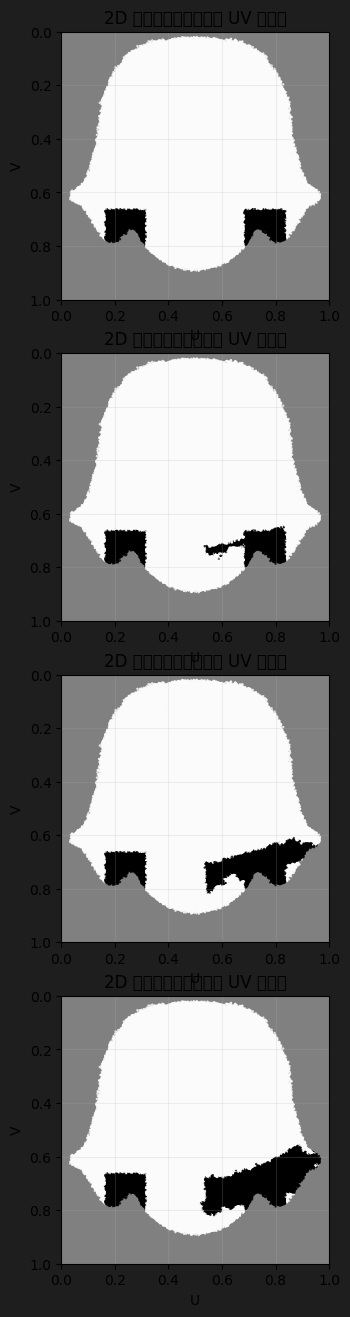

In [38]:
# 以髮根 UV 座標繪製髮絲顏色的 2D 點雲分布
# 每個點代表一根髮絲，顏色來自 strand_colors
n_plots = len(iter_strand_colors)
fig, axes = plt.subplots(n_plots, 1, figsize=(16, 4 * n_plots))
fig.set_facecolor("#1e1e1e")
for ax in axes:
    ax.set_facecolor("gray")    # 繪圖區域的底色（scatter/imshow 底下那層）

for i, strand_colors in enumerate(iter_strand_colors):
    draw_strand_uv_color_distribution(root_uv, strand_colors, ax=axes[i], show=False)

plt.show()

## 6. 存成 `coloring_by_strand` 的 per-strand template 格式，並用 Blender 渲染正面照

`coloring_by_strand/generate_highlight_render_by_strand.py` 這條 pipeline 認得的 per-strand
template，就是 `generate_highlight_templates_by_strand.py` 產生的格式，一個 npz 內含：

| key | 說明 |
|---|---|
| `highlighted` | `(nr_strands,)` bool，這根髮絲要不要套用 `highlight_color` |
| `highlight_color` | `(nr_strands, 3)` float32，`[0,1]` 的 RGB — 每根髮絲自己的顏色 |
| `root_uv` | `(nr_strands, 2)` float32 — 這個 template 是針對哪個 `root_uv` 排列烤出來的，渲染時會拿來跟 `--input_npz` 自己的 `root_uv` 核對，確保沒有對錯髮型/順序 |

跟舊版 `coloring_by_grid` 的 `{mask, grid_size, rgb}` 格式不同——這裡完全不需要 n×n grid，Blender
渲染端 (`generate_highlight_render_by_strand.py`) 也不會再做任何 UV 查表，直接把 `highlighted[k]` /
`highlight_color[k]` 逐一套用到第 `k` 根髮絲上。

把第 5 節算好的 `strand_highlighted` / `strand_colors` 存成這個格式（`mask` 全開的等效寫法 = 全部
`highlighted=True`，整顆頭都交給查表結果決定顏色），再直接呼叫 Blender 端的
`coloring_by_strand/generate_highlight_render_by_strand.py`（不需要也沒有 `--use_template_color`
這種 flag——per-strand template 本來就是每根髮絲都各自帶著自己的顏色），渲染一張正面照。

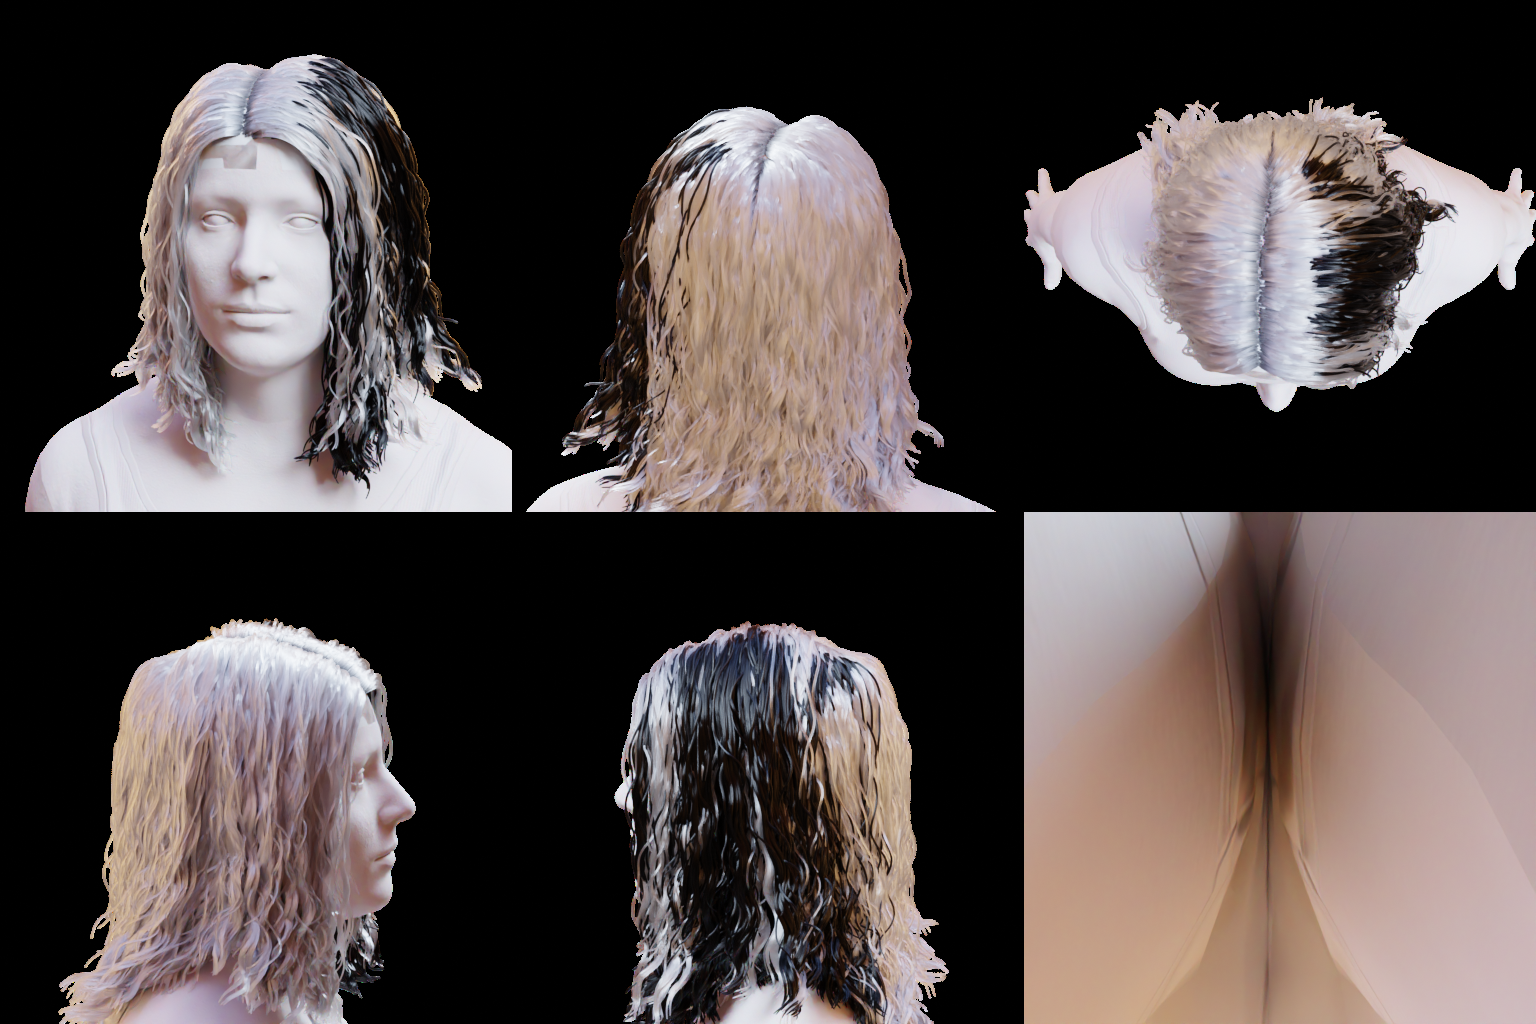

wrote /home/kyh/Desktop/P76154862/highlighting/generate_from_3D_models/coloring_by_strand/median_templates/template_notebook_color_matrix.npz
執行 Blender multi-view 渲染...
00:00.296  blend            | Read blend: "/home/kyh/Desktop/P76154862/NCKU_3D_hair_reconstruction/inference/assets/blender_vis_base_v26_with_shrinkwrap_full_base.blend"
00:16.041  render           | Saved: '/home/kyh/Desktop/P76154862/highlighting/generate_from_3D_models/scalp_grid_volume_sample/output/iter_1/front.png'
00:26.344  render           | Saved: '/home/kyh/Desktop/P76154862/highlighting/generate_from_3D_models/scalp_grid_volume_sample/output/iter_1/_multiview_tmp.png'
00:36.489  render           | Saved: '/home/kyh/Desktop/P76154862/highlighting/generate_from_3D_models/scalp_grid_volume_sample/output/iter_1/_multiview_tmp.png'
00:46.724  render           | Saved: '/home/kyh/Desktop/P76154862/highlighting/generate_from_3D_models/scalp_grid_volume_sample/output/iter_1/_multiview_tmp.png'
00:56.441  render    

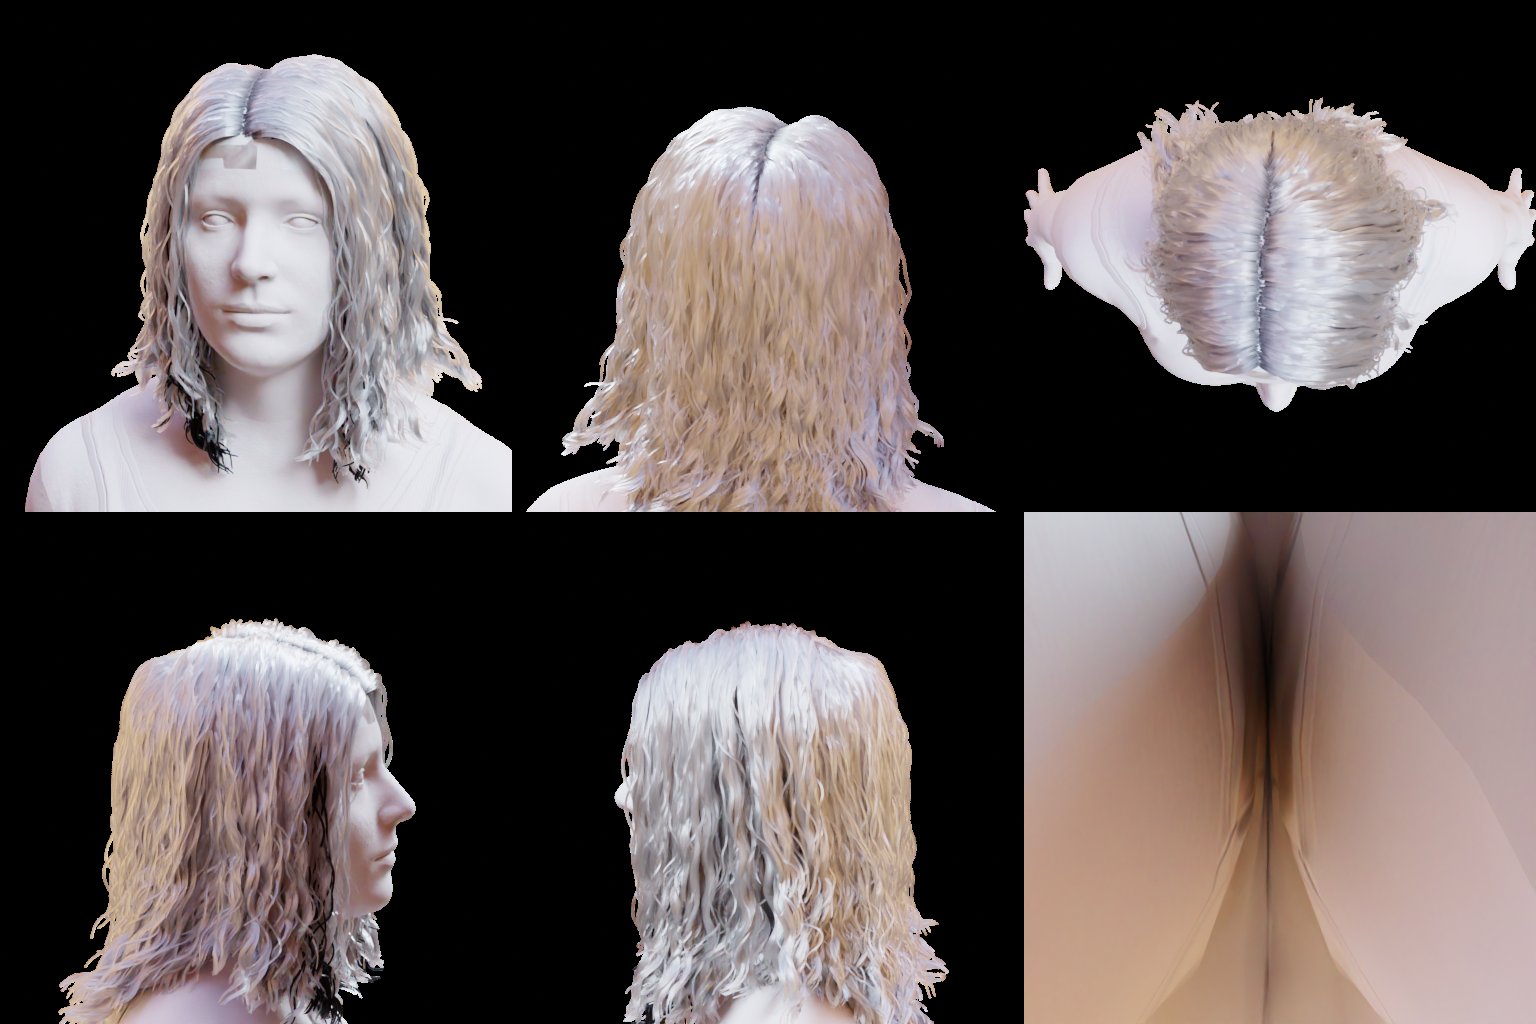

/home/kyh/Desktop/P76154862/highlighting/generate_from_3D_models/scalp_grid_volume_sample/output/iter_1/scalp_grid.npz
/home/kyh/Desktop/P76154862/highlighting/generate_from_3D_models/scalp_grid_volume_sample/output/iter_1/scalp_grid_rgb.jpg
wrote /home/kyh/Desktop/P76154862/highlighting/generate_from_3D_models/coloring_by_strand/median_templates/template_notebook_color_matrix.npz
執行 Blender multi-view 渲染...


KeyboardInterrupt: 

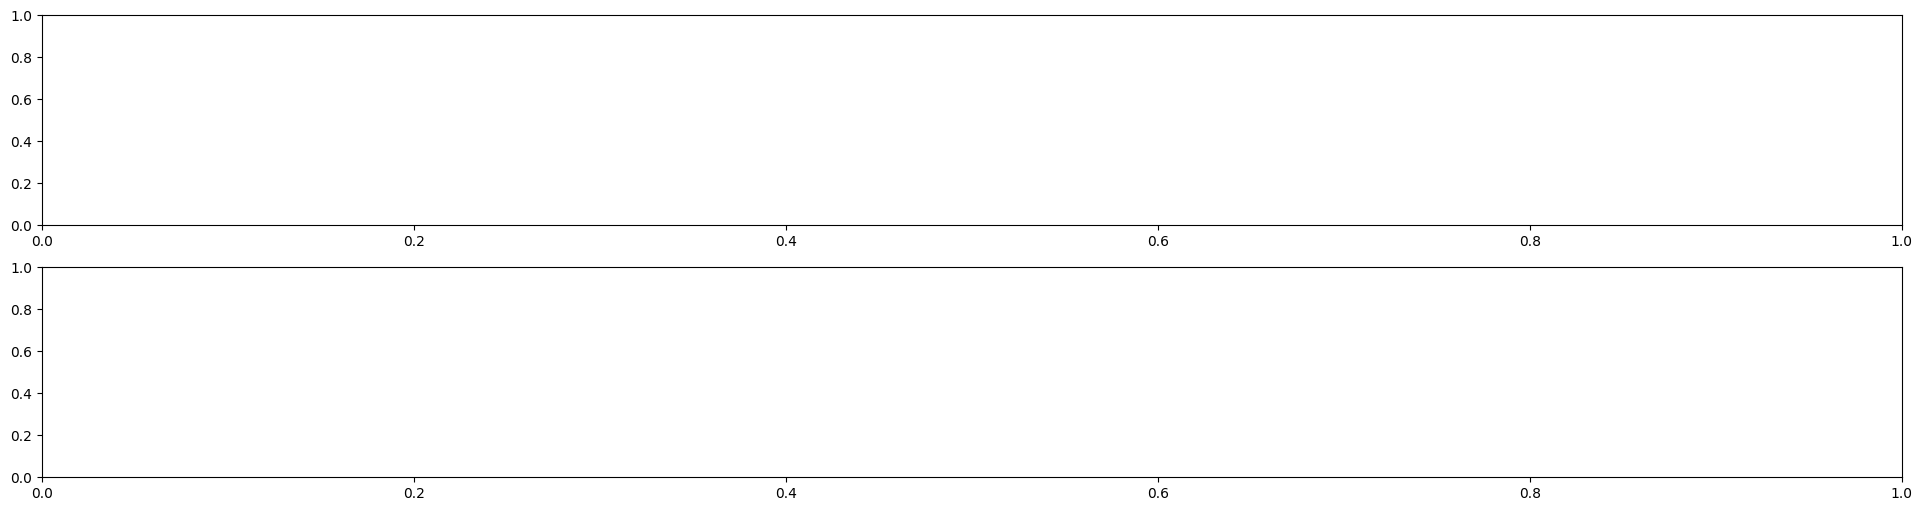

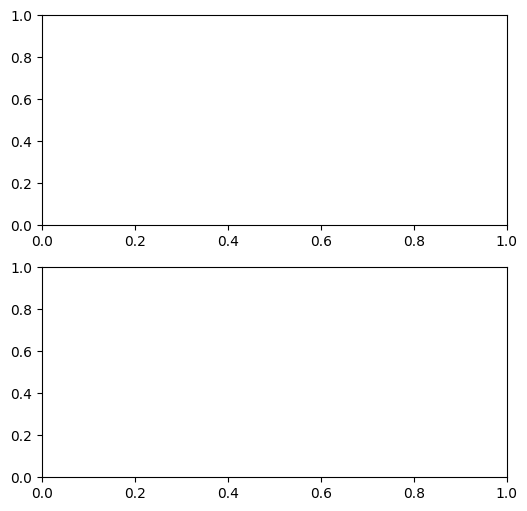

In [34]:
from IPython.display import Image, display
fig, ax = plt.subplots(2,1,figsize=(6*(n_iter+1), 6))
GEN3D_DIR = os.path.join(PROJECT_ROOT, "highlighting", "generate_from_3D_models")
CODE_BY_STRAND_DIR = os.path.join(GEN3D_DIR, "coloring_by_strand")

RENDER_SCRIPT = os.path.join(CODE_BY_STRAND_DIR, "generate_highlight_render_by_strand.py")
RUN_BLENDER_SH = os.path.join(CODE_BY_STRAND_DIR, "run_highlight_render.sh")
BLENDER_PATH = "/home/kyh/blender/blender"


fig, ax = plt.subplots(2,1,figsize=(6, 6))

base_npz_path = save_template_npz(
    template_dir=os.path.join(PROJECT_ROOT, "highlighting", "generate_from_3D_models", "coloring_by_strand", "base_templates"),
    sample_name=os.path.basename(HAIRSTYLE_DIR),
    strands_source_name="full",
    root_uv=root_uv,
    strand_highlighted=strand_highlighted,
    strand_colors=base_strand_colors,
    grid_size=N,
    color_source="scalp_grid_and_strands_demo_by_strand.ipynb 第 5 節自訂的 color_matrix",
    source="scalp_grid_and_strands_demo_by_strand.ipynb",
)

run_blender_render(
    base_npz_path,
    out_dir=os.path.join(HERE, "output", "base"),
    strands_npz=STRANDS_NPZ,
    dataset_path=DATASET_PATH,
    here=HERE,
    run_blender_sh=RUN_BLENDER_SH,
    blender_path=BLENDER_PATH,
    render_script=RENDER_SCRIPT
)


display(Image(filename=os.path.join(HERE, "output", "base", "front_multiview.png")))

for i in range(1, n_iter):
    strand_color_i = iter_strand_colors[i]
    npz_path = save_template_npz(
        template_dir=os.path.join(PROJECT_ROOT, "highlighting", "generate_from_3D_models", "coloring_by_strand", "median_templates"),
        sample_name=os.path.basename(HAIRSTYLE_DIR),
        strands_source_name="full",
        root_uv=root_uv,
        strand_highlighted=strand_highlighted,
        strand_colors=strand_color_i,
        grid_size=N,
        color_source="scalp_grid_and_strands_demo_by_strand.ipynb 第 5 節自訂的 color_matrix",
        source="scalp_grid_and_strands_demo_by_strand.ipynb",
    )

    run_blender_render(
        npz_path,
        out_dir=os.path.join(HERE, "output", "iter_" + str(i)),
        strands_npz=STRANDS_NPZ,
        dataset_path=DATASET_PATH,
        here=HERE,
        run_blender_sh=RUN_BLENDER_SH,
        blender_path=BLENDER_PATH,
        render_script=RENDER_SCRIPT,
    )